<a href="https://colab.research.google.com/github/cristiandmarin7-jpg/CoderhouseCristianM/blob/main/Proyecto_Final_NLP_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final
## Procesamiento de Lenguaje Natural y Deep Learning

**Autor:** Cristian David Marin Castiblanco

**Materia:** NLP & Deep Learning aplicado a Ciencia de Datos

---

### Objetivo

Construir un clasificador de noticias falsas utilizando técnicas de Procesamiento de Lenguaje Natural (NLP), representación TF-IDF y un modelo de Deep Learning implementado en PyTorch.

#Librerias

In [1]:
!pip install nltk spacy wordcloud torch torchvision torchaudio scikit-learn seaborn -q
!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from collections import Counter

from wordcloud import WordCloud

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

#Cargar los dataset

In [2]:
#cargar datos
#datset fake news
fake = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRZvx2B3cktekM0WmcFgccUsa3ObrEidTwHgLtfzTrZiNSBXCyJnX_AKxjJPiaPrORosatg4AJctOl2/pub?output=csv")
#dataset true news
true = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTlm8KWTjUh4NyHoJbeN3qd2zR682wwDC2DfTwrkcjsatPP0zqLcCD5KtXxDPjVXcElM4YHUCzbPk3x/pub?gid=1969534897&single=true&output=csv")

In [3]:
print(fake.shape)
print(true.shape)

fake.head()

#Agregamos etiquetas para la clasificación
fake["label"] = 0   # Noticias falsas
true["label"] = 1   # Noticias verdaderas

(23481, 4)
(21417, 4)


In [4]:
#Procedemos a unir ambos datsets
df = pd.concat([fake, true], ignore_index=True)
print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian C...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke ...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Duri...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [5]:
# Reducir el dataset manteniendo el equilibrio entre clases
df = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=5000, random_state=42))
      .reset_index(drop=True)
)

print(df.shape)
print(df["label"].value_counts())

(10000, 5)
label
0    5000
1    5000
Name: count, dtype: int64


/tmp/ipykernel_1033/1835359562.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=5000, random_state=42))


In [6]:
#Verificamos si tenemos valores faltantes en el dataset

print(df["text"].isna().sum())


#Reemplazamos los valores nulos por una cadena vacia y convierto toda la columna a texto
df["text"] = df["text"].fillna("").astype(str)

117


#Análisis Exploratorio (EDA)

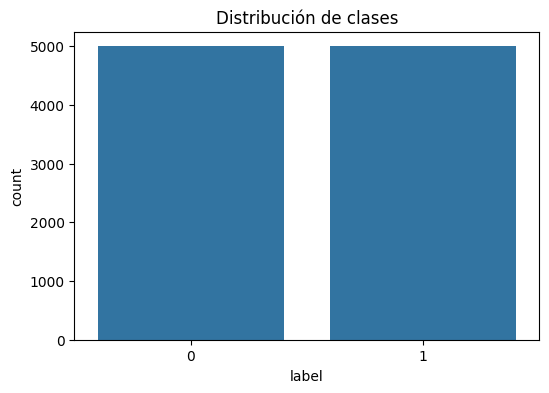

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Distribución de clases")
plt.show()

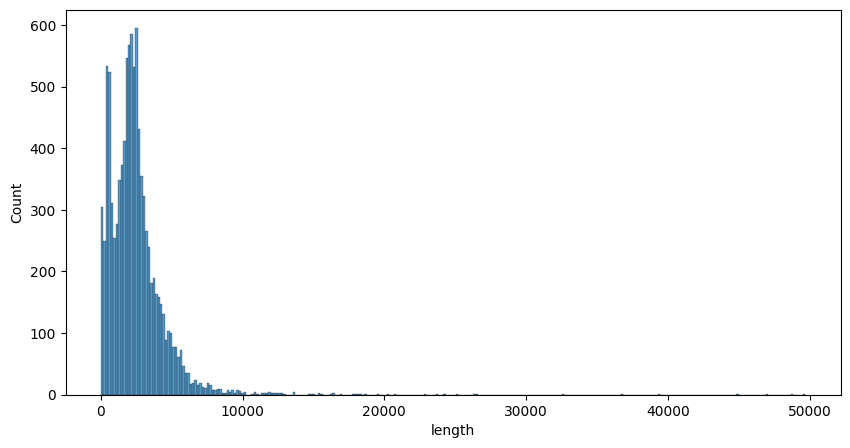

In [8]:
df["length"] = df["text"].str.len()
plt.figure(figsize=(10,5))
sns.histplot(df["length"])
plt.show()

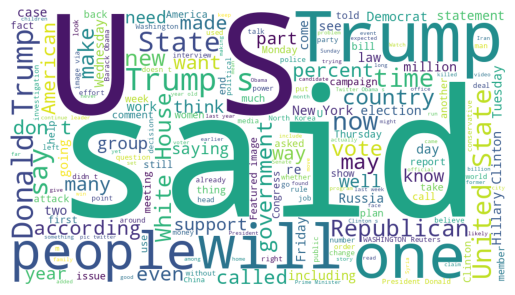

In [9]:
texto = "".join(df["text"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(texto)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

#Preprocesamiento

REGEX

In [10]:
def limpiar(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"[^a-zA-Z ]", "", texto)
    return texto

df["clean"] = df["text"].apply(limpiar)

#Tokenización

In [11]:
df["tokens"] = df["clean"].apply(word_tokenize)

#Lematización NLTK

In [12]:
lemmatizer = WordNetLemmatizer()

def lemma_nltk(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]
df["lemma_nltk"] = df["tokens"].apply(lemma_nltk)

#Lematización spaCy

In [13]:
nlp = spacy.load("en_core_web_sm")

def lemma_spacy(texto):
    doc = nlp(texto)
    return [token.lemma_ for token in doc]
df["lemma_spacy"] = df["clean"].apply(lemma_spacy)

#Ahora comparamos los dos modelos de lematización

In [14]:
print(df["lemma_nltk"][0][:20])
print(df["lemma_spacy"][0][:20])

[]
[]


#TF-IDF

In [15]:
#Convertimos las listas de lemas nuevamente a texto:
df["final_text"] = df["lemma_spacy"].apply(lambda x: " ".join(x))

In [16]:
# Vectorización:

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["final_text"])

In [17]:
y = df["label"]

#Train/Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# pasar al tensor
X_train = torch.FloatTensor(X_train.toarray())
X_test = torch.FloatTensor(X_test.toarray())

y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

#Crear Dataset

In [20]:
class NewsDataset(Dataset):

    def __init__(self, X, y):

        self.X = X

        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

#DataLoader

In [21]:
train_loader = DataLoader(
    NewsDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    NewsDataset(X_test, y_test),
    batch_size=64
)

#Modelado DL

In [22]:
class TextClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(5000,512),

            nn.BatchNorm1d(512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512,128),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128,2)

        )

    def forward(self,x):

        return self.net(x)

#Entrenamos el modelo

In [23]:
model = TextClassifier()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

#Resultados

In [24]:
model.eval()

predicciones = []

reales = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        pred = torch.argmax(outputs,1)

        predicciones.extend(pred.numpy())

        reales.extend(y_batch.numpy())

In [25]:
print(classification_report(reales,predicciones))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1012
           1       0.49      1.00      0.66       988

    accuracy                           0.49      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.24      0.49      0.33      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
print("Accuracy:",accuracy_score(reales,predicciones))

Accuracy: 0.494


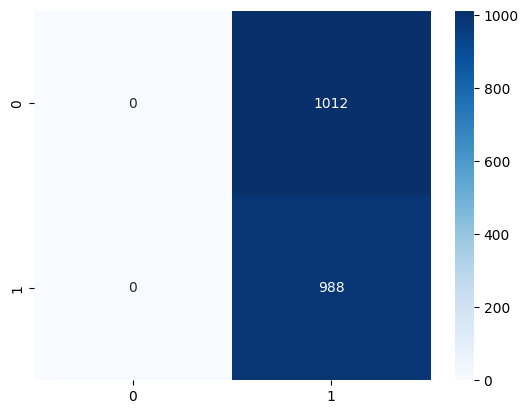

In [27]:
cm = confusion_matrix(reales,predicciones)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.show()

#Conclusiones

1.¿Por qué TF-IDF es mejor que el conteo simple?

Porque pondera las palabras según su importancia en el corpus, reduciendo el peso de términos muy frecuentes y destacando los más discriminativos.

2.¿Qué diferencias viste entre NLTK y spaCy?

spaCy suele producir lemas más precisos gracias a su análisis lingüístico; NLTK puede requerir información adicional de la categoría gramatical para obtener resultados similares.

3.¿Qué limitaciones tiene el modelo?

TF-IDF no representa el contexto ni el orden de las palabras, y una red densa no captura relaciones semánticas complejas.

4.¿Qué mejorarías?

Probar embeddings (Word2Vec, GloVe), modelos recurrentes (LSTM/GRU) o transformadores como BERT, además de optimizar hiperparámetros.